In [ ]:
import os
import pandas as pd
import numpy as np
import datetime
from scipy import sparse
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount = False)

Mounted at /content/drive


In [ ]:
path = "/content/drive/MyDrive/Math168/Data/Finalized Data"
print(os.listdir(path))

['csv_merge.m', 'merged_transactions_test.csv', 'merged_transactions_train.csv', 'Finalized Drafts', 'merge.ipynb', 'features_train.csv', 'features_test.csv', 'Isolation Forests']


In [ ]:
test = pd.read_csv(path + "/features_test.csv", index_col=0)
train = pd.read_csv(path + "/features_train.csv", index_col=0)

### Random Forest Model

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    auc
)

In [ ]:
candidate_features = [
    'amt', 'lat', 'long', 'city_pop', 'category', 'unix_time',
       'merch_lat', 'merch_long', 'log_amt',
       'merchant_txn_count_past', 'merchant_unique_cards_past',
       'card_txn_count_1h', 'amt_to_card_median', 'amt_to_category_median',
       'hour_of_day', 'day_of_week', 'is_weekend', 'dist_home_merchant_km',
       'recency_sec', 'dist_prev_merchant_km', 'implied_speed_kmh',
       'State Fraud Rate', 'Avg Card Dist (km)', 'Dist Ratio',
       'Log Distance (km)', 'Bin Fraud Rate', 'CCHScore_ST', 'MCScore_ST',
       'TXScore_ST', 'CCHScore_MT', 'MCScore_MT', 'TXScore_MT', 'CCHScore_LT',
       'MCScore_LT', 'TXScore_LT', 'CCHScore_ST_birank', 'MCScore_ST_birank',
       'TXScore_ST_birank', 'CCHScore_MT_birank', 'MCScore_MT_birank',
       'TXScore_MT_birank', 'CCHScore_LT_birank', 'MCScore_LT_birank',
       'TXScore_LT_birank', 'card_birank', 'merchant_birank'
]
intrinsic_features = [
     'amt', 'lat', 'long', 'city_pop', 'category', 'unix_time',
       'merch_lat', 'merch_long', 'log_amt',
       'merchant_txn_count_past', 'merchant_unique_cards_past',
       'card_txn_count_1h', 'amt_to_card_median', 'amt_to_category_median',
       'hour_of_day', 'day_of_week', 'is_weekend', 'dist_home_merchant_km',
       'recency_sec', 'dist_prev_merchant_km', 'implied_speed_kmh',
       'State Fraud Rate', 'Avg Card Dist (km)', 'Dist Ratio',
       'Log Distance (km)', 'Bin Fraud Rate'
]

feature_cols = [c for c in candidate_features if c in train.columns and c in test.columns]
print("Using features:", feature_cols)

Using features: ['amt', 'lat', 'long', 'city_pop', 'category', 'unix_time', 'merch_lat', 'merch_long', 'log_amt', 'merchant_txn_count_past', 'merchant_unique_cards_past', 'card_txn_count_1h', 'amt_to_card_median', 'amt_to_category_median', 'hour_of_day', 'day_of_week', 'is_weekend', 'dist_home_merchant_km', 'recency_sec', 'dist_prev_merchant_km', 'implied_speed_kmh', 'State Fraud Rate', 'Avg Card Dist (km)', 'Dist Ratio', 'Log Distance (km)', 'Bin Fraud Rate', 'CCHScore_ST', 'MCScore_ST', 'TXScore_ST', 'CCHScore_MT', 'MCScore_MT', 'TXScore_MT', 'CCHScore_LT', 'MCScore_LT', 'TXScore_LT', 'CCHScore_ST_birank', 'MCScore_ST_birank', 'TXScore_ST_birank', 'CCHScore_MT_birank', 'MCScore_MT_birank', 'TXScore_MT_birank', 'CCHScore_LT_birank', 'MCScore_LT_birank', 'TXScore_LT_birank', 'card_birank', 'merchant_birank']


In [ ]:
X_train = train[feature_cols].copy()
y_train = train['is_fraud'].astype(int).copy()

X_test = test[feature_cols].copy()
y_test = test['is_fraud'].astype(int).copy()

print("Train size:", X_train.shape, "Fraud rate:", y_train.mean())
print("Test size :", X_test.shape, "Fraud rate:", y_test.mean())

Train size: (1296675, 46) Fraud rate: 0.005788651743883394
Test size : (87645, 46) Fraud rate: 0.004084659706771635


In [ ]:
categorical_cols = [c for c in feature_cols if X_train[c].dtype == 'object' or str(X_train[c].dtype).startswith('category')]
numeric_cols = [c for c in feature_cols if c not in categorical_cols]

print("Numeric cols:", numeric_cols)
print("Categorical cols:", categorical_cols)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols),
    ],
    remainder='drop'
)

Numeric cols: ['amt', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat', 'merch_long', 'log_amt', 'merchant_txn_count_past', 'merchant_unique_cards_past', 'card_txn_count_1h', 'amt_to_card_median', 'amt_to_category_median', 'hour_of_day', 'day_of_week', 'is_weekend', 'dist_home_merchant_km', 'recency_sec', 'dist_prev_merchant_km', 'implied_speed_kmh', 'State Fraud Rate', 'Avg Card Dist (km)', 'Dist Ratio', 'Log Distance (km)', 'Bin Fraud Rate', 'CCHScore_ST', 'MCScore_ST', 'TXScore_ST', 'CCHScore_MT', 'MCScore_MT', 'TXScore_MT', 'CCHScore_LT', 'MCScore_LT', 'TXScore_LT', 'CCHScore_ST_birank', 'MCScore_ST_birank', 'TXScore_ST_birank', 'CCHScore_MT_birank', 'MCScore_MT_birank', 'TXScore_MT_birank', 'CCHScore_LT_birank', 'MCScore_LT_birank', 'TXScore_LT_birank', 'card_birank', 'merchant_birank']
Categorical cols: ['category']


In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,              # APATE mentions 500; 300 is a good starter
    random_state=42,
    n_jobs=-1,
    class_weight='balanced_subsample',  # simple imbalance handling
    min_samples_split=20,
    min_samples_leaf=5,
    verbose=1
)

clf = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', rf)
])

# Train
clf.fit(X_train, y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed: 10.0min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed: 21.8min finished


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['amt', 'lat', 'long',
                                                   'city_pop', 'unix_time',
                                                   'merch_lat', 'merch_long',
                                                   'log_amt',
                                                   'merchant_txn_count_past',
                                                   'merchant_unique_cards_past',
                                                   'card_txn_count_1h',
                                                   'amt_to_card_median',
                                                   'amt_to_category_median',
                                                   'hour_of_day', 'day_...
                                                   'CCHScore_ST', 'MCScore_ST',
                                                   'TXScore_ST', 'CCHScore_MT',
                                                   'MCScore_MT', ...]),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['category'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced_subsample',
                                        min_samples_leaf=5,
                                        min_samples_split=20, n_jobs=-1,
                                        random_state=42, verbose=1))])

In [ ]:
# =====================================================
# 5) Evaluate
# =====================================================
y_score = clf.predict_proba(X_test)[:, 1]
y_pred_05 = (y_score >= 0.5).astype(int)

roc_auc = roc_auc_score(y_test, y_score)
pr_auc = average_precision_score(y_test, y_score)

print("\n=== Random Forest Baseline Results ===")
print(f"ROC-AUC: {roc_auc:.6f}")
print(f"PR-AUC : {pr_auc:.6f}")

print("\nConfusion Matrix @ threshold=0.5")
print(confusion_matrix(y_test, y_pred_05))

print("\nClassification Report @ threshold=0.5")
print(classification_report(y_test, y_pred_05, digits=4))

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.5s



=== Random Forest Baseline Results ===
ROC-AUC: 0.995301
PR-AUC : 0.861799

Confusion Matrix @ threshold=0.5
[[87230    57]
 [   86   272]]

Classification Report @ threshold=0.5
              precision    recall  f1-score   support

           0     0.9990    0.9993    0.9992     87287
           1     0.8267    0.7598    0.7918       358

    accuracy                         0.9984     87645
   macro avg     0.9129    0.8796    0.8955     87645
weighted avg     0.9983    0.9984    0.9983     87645



[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    1.1s finished


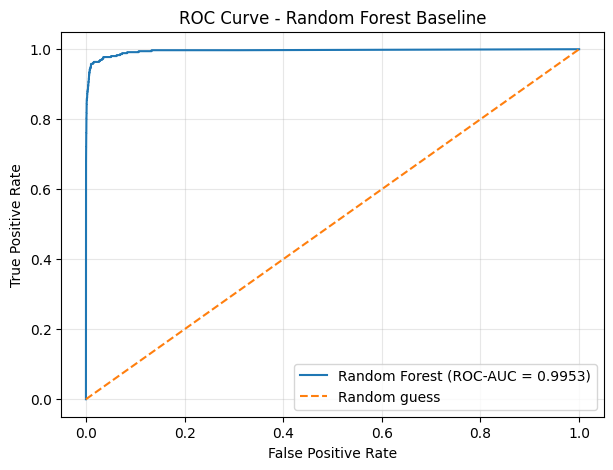

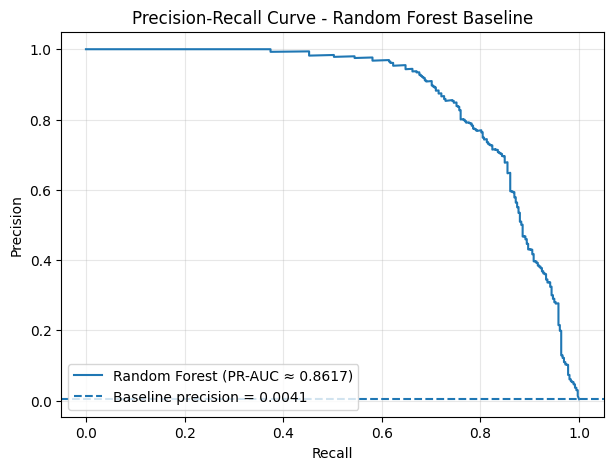

In [ ]:
# y_test and y_score already exist from your code
# y_score = clf.predict_proba(X_test)[:, 1]

# -----------------------------
# 1) ROC curve
# -----------------------------
fpr, tpr, roc_thresholds = roc_curve(y_test, y_score)
roc_auc_value = auc(fpr, tpr)  # same idea as roc_auc_score

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'Random Forest (ROC-AUC = {roc_auc_value:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest Baseline')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# -----------------------------
# 2) Precision-Recall curve
# -----------------------------
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_score)
pr_auc_value = auc(recall, precision)  # close to average_precision_score, but not identical

# Baseline precision = fraud prevalence
baseline_precision = y_test.mean()

plt.figure(figsize=(7,5))
plt.plot(recall, precision, label=f'Random Forest (PR-AUC ≈ {pr_auc_value:.4f})')
plt.axhline(baseline_precision, linestyle='--', label=f'Baseline precision = {baseline_precision:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Random Forest Baseline')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.show()

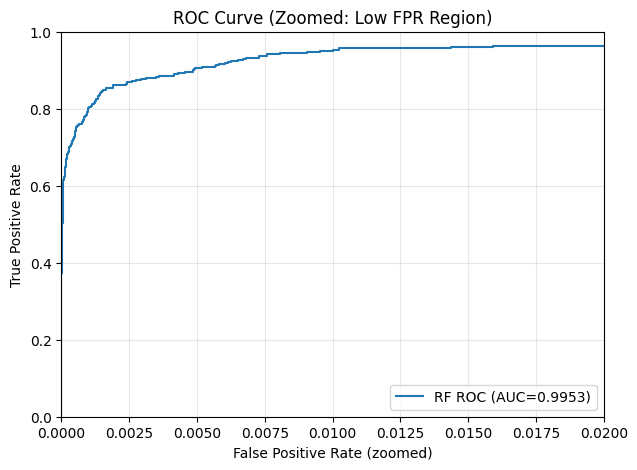

In [ ]:
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'RF ROC (AUC={roc_auc_value:.4f})')
plt.xlim(0, 0.02)   # zoom into low false positive region
plt.ylim(0, 1.0)
plt.xlabel('False Positive Rate (zoomed)')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Zoomed: Low FPR Region)')
plt.grid(alpha=0.3)
plt.legend(loc='lower right')
plt.show()

In [ ]:
preprocessor_fitted = clf.named_steps["preprocess"]
rf_fitted = clf.named_steps["model"]

feature_names_out = preprocessor_fitted.get_feature_names_out()

importances = rf_fitted.feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names_out,
    "importance": importances
}).sort_values("importance", ascending=False)

print("\nTop 20 transformed feature importances:")
print(importance_df.head(20))


Top 20 transformed feature importances:
                        feature  importance
0                      num__amt    0.192209
7                  num__log_amt    0.182054
12  num__amt_to_category_median    0.113467
11      num__amt_to_card_median    0.095779
13             num__hour_of_day    0.057478
25             num__CCHScore_ST    0.046041
27              num__TXScore_ST    0.040321
44         num__merchant_birank    0.022435
40      num__CCHScore_LT_birank    0.021039
17             num__recency_sec    0.017078
47  cat__category_gas_transport    0.017051
10       num__card_txn_count_1h    0.015508
31             num__CCHScore_LT    0.015502
19       num__implied_speed_kmh    0.013956
43             num__card_birank    0.012843
34      num__CCHScore_ST_birank    0.007474
37      num__CCHScore_MT_birank    0.006936
28             num__CCHScore_MT    0.006318
41       num__MCScore_LT_birank    0.005516
49    cat__category_grocery_pos    0.004570


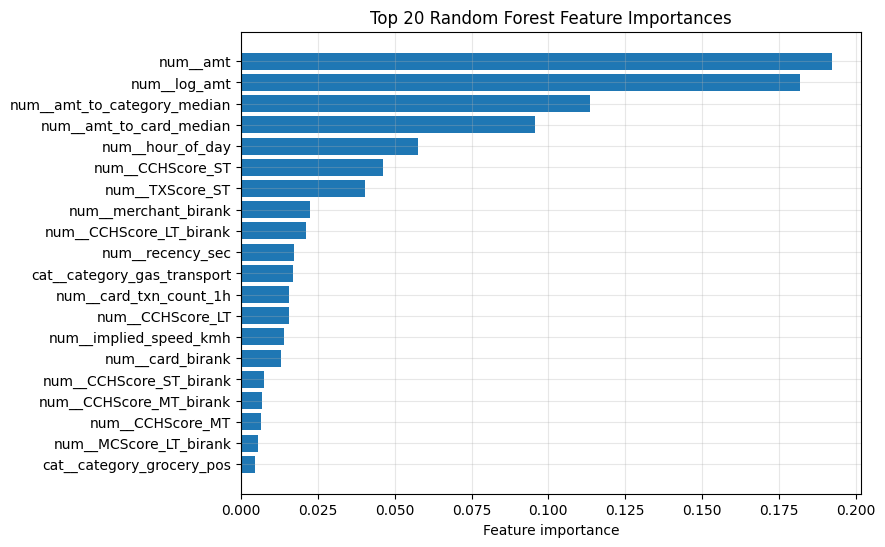

In [ ]:
top_n = 20
top_imp = importance_df.head(top_n).iloc[::-1]

plt.figure(figsize=(8, 6))
plt.barh(top_imp["feature"], top_imp["importance"])
plt.xlabel("Feature importance")
plt.title(f"Top {top_n} Random Forest Feature Importances")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# =====================================================
# 0) Time-based split: fit / validation
# =====================================================
val_frac = 0.20
split_idx = int(len(train) * (1 - val_frac))

train_fit = train.iloc[:split_idx].copy()
train_val = train.iloc[split_idx:].copy()

X_fit = train_fit[feature_cols].copy()
y_fit = train_fit["is_fraud"].astype(int).copy()

X_val = train_val[feature_cols].copy()
y_val = train_val["is_fraud"].astype(int).copy()

X_test = test[feature_cols].copy()
y_test = test["is_fraud"].astype(int).copy()

print("Fit size :", X_fit.shape, "Fraud rate:", y_fit.mean())
print("Val size :", X_val.shape, "Fraud rate:", y_val.mean())
print("Test size:", X_test.shape, "Fraud rate:", y_test.mean())

Fit size : (1037340, 46) Fraud rate: 0.005753176393467908
Val size : (259335, 46) Fraud rate: 0.005930553145545337
Test size: (87645, 46) Fraud rate: 0.004084659706771635


In [ ]:
# =====================================================
# 1) Fit model on fit split only
# =====================================================
clf.fit(X_fit, y_fit)
y_val_score = clf.predict_proba(X_val)[:, 1]

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:  7.8min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed: 16.6min finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.8s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    1.7s finished


In [19]:
# =====================================================
# 2) Build threshold table on validation
# =====================================================
thresholds = np.unique(np.round(y_val_score, 12))

rows = []
for t in thresholds:
    y_val_pred = (y_val_score >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, y_val_pred).ravel()

    fpr_val = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    precision = precision_score(y_val, y_val_pred, zero_division=0)
    recall = recall_score(y_val, y_val_pred, zero_division=0)
    f1 = f1_score(y_val, y_val_pred, zero_division=0)
    bal_acc = balanced_accuracy_score(y_val, y_val_pred)

    rows.append({
        "threshold": float(t),
        "fpr": fpr_val,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "balanced_accuracy": bal_acc,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
    })

threshold_df = pd.DataFrame(rows).sort_values("threshold").reset_index(drop=True)

In [20]:
# =====================================================
# 3A) Best F1
# =====================================================
best_f1_row = threshold_df.loc[threshold_df["f1"].idxmax()].copy()
best_f1_threshold = float(best_f1_row["threshold"])

# =====================================================
# 3B) Best precision subject to recall >= 0.80
# =====================================================
target_recall = 0.80
eligible_prec = threshold_df[threshold_df["recall"] >= target_recall].copy()

if len(eligible_prec) == 0:
    raise ValueError(f"No threshold achieves recall >= {target_recall:.2f} on validation.")

best_prec_row = eligible_prec.sort_values(
    ["precision", "recall", "threshold"],
    ascending=[False, False, False]
).iloc[0].copy()
best_prec_threshold = float(best_prec_row["threshold"])

# =====================================================
# 3C) Best recall subject to FPR <= 0.1%
# =====================================================
target_fpr = 0.001  # 0.1%
eligible_recall = threshold_df[threshold_df["fpr"] <= target_fpr].copy()

if len(eligible_recall) == 0:
    raise ValueError(f"No threshold achieves FPR <= {target_fpr:.4f} on validation.")

best_recall_row = eligible_recall.sort_values(
    ["recall", "precision", "threshold"],
    ascending=[False, False, False]
).iloc[0].copy()
best_recall_threshold = float(best_recall_row["threshold"])

print("\n=== Validation-selected thresholds ===")

print("\nA) Best F1")
print(best_f1_row)

print("\nB) Best precision subject to recall >= 0.80")
print(best_prec_row)

print("\nC) Best recall subject to FPR <= 0.1%")
print(best_recall_row)


=== Validation-selected thresholds ===

A) Best F1
threshold                 0.477940
fpr                       0.000756
precision                 0.864958
recall                    0.812094
f1                        0.837693
balanced_accuracy         0.905669
tn                   257602.000000
fp                      195.000000
fn                      289.000000
tp                     1249.000000
Name: 24342, dtype: float64

B) Best precision subject to recall >= 0.80
threshold                 0.492816
fpr                       0.000687
precision                 0.874290
recall                    0.800390
f1                        0.835709
balanced_accuracy         0.899852
tn                   257620.000000
fp                      177.000000
fn                      307.000000
tp                     1231.000000
Name: 24379, dtype: float64

C) Best recall subject to FPR <= 0.1%
threshold                 0.431830
fpr                       0.000981
precision                 0.834964
rec

In [21]:
# =====================================================
# 4) Refit on ALL training data
# =====================================================
X_train_full = train[feature_cols].copy()
y_train_full = train["is_fraud"].astype(int).copy()

clf.fit(X_train_full, y_train_full)
y_test_score = clf.predict_proba(X_test)[:, 1]

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed: 10.3min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed: 22.4min finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.3s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.6s finished


In [26]:
# =====================================================
# 5) Helper to evaluate on test
# =====================================================
def evaluate_on_test(y_true, y_score, threshold, label):
    y_pred = (y_score >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    fpr_val = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    bal_acc = balanced_accuracy_score(y_true, y_pred)

    # PR-AUC from scores, not thresholded predictions
    ap = average_precision_score(y_true, y_score)

    # Optional trapezoidal PR-AUC
    pr_precision, pr_recall, _ = precision_recall_curve(y_true, y_score)
    pr_auc_trap = auc(pr_recall, pr_precision)

    print(f"\n=== Test results: {label} ===")
    print(f"Threshold     : {threshold:.6f}")
    print(f"FPR           : {fpr_val:.6f}")
    print(f"Precision     : {precision:.6f}")
    print(f"Recall        : {recall:.6f}")
    print(f"F1            : {f1:.6f}")
    print(f"Balanced Acc. : {bal_acc:.6f}")
    print(f"PR-AUC (AP)   : {ap:.6f}")
    print(f"PR-AUC (trap) : {pr_auc_trap:.6f}")
    print("\nConfusion Matrix")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification Report")
    print(classification_report(y_true, y_pred, digits=4))

    return {
        "setting": label,
        "threshold": threshold,
        "fpr": fpr_val,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "balanced_accuracy": bal_acc,
        "pr_auc_ap": ap,
        "pr_auc_trap": pr_auc_trap,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
    }

In [27]:
# =====================================================
# 6) Evaluate all three on test
# =====================================================
results = []
results.append(
    evaluate_on_test(
        y_test,
        y_test_score,
        best_f1_threshold,
        "Best F1 on validation",
    )
)
results.append(
    evaluate_on_test(
        y_test,
        y_test_score,
        best_prec_threshold,
        "Best precision with recall >= 0.80 on validation",
    )
)
results.append(
    evaluate_on_test(
        y_test,
        y_test_score,
        best_recall_threshold,
        "Best recall with FPR <= 0.1% on validation",
    )
)

results_df = pd.DataFrame(results)

print("\n=== Summary of three threshold strategies on test ===")
print(
    results_df[
        [
            "setting",
            "threshold",
            "fpr",
            "precision",
            "recall",
            "f1",
            "balanced_accuracy",
            "tn",
            "fp",
            "fn",
            "tp",
        ]
    ]
)


=== Test results: Best F1 on validation ===
Threshold     : 0.477940
FPR           : 0.000779
Precision     : 0.800587
Recall        : 0.762570
F1            : 0.781116
Balanced Acc. : 0.880895
PR-AUC (AP)   : 0.861799
PR-AUC (trap) : 0.861704

Confusion Matrix
[[87219    68]
 [   85   273]]

Classification Report
              precision    recall  f1-score   support

           0     0.9990    0.9992    0.9991     87287
           1     0.8006    0.7626    0.7811       358

    accuracy                         0.9983     87645
   macro avg     0.8998    0.8809    0.8901     87645
weighted avg     0.9982    0.9983    0.9982     87645


=== Test results: Best precision with recall >= 0.80 on validation ===
Threshold     : 0.492816
FPR           : 0.000699
Precision     : 0.816817
Recall        : 0.759777
F1            : 0.787265
Balanced Acc. : 0.879539
PR-AUC (AP)   : 0.861799
PR-AUC (trap) : 0.861704

Confusion Matrix
[[87226    61]
 [   86   272]]

Classification Report
            